# Student Academic Risk Prediction
## Notebook 03: Exploratory Data Analysis

In this notebook I explore the cleaned dataset visually and statistically 
to understand the distribution of features, relationships between variables, 
and patterns that separate at-risk students from passing students.

This analysis directly informs my feature engineering and modelling decisions.

### Imports & Load


In [40]:
# loading libraries and setting a global colour convention
# I define COLORS once here and reuse it everywhere — no inconsistency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.2)

# global colour map — used consistently in every chart
PALETTE = {'Passing': '#2ecc71', 'At-Risk': '#e74c3c'}
COLOR_LIST = ['#2ecc71', '#e74c3c']  # index 0 = Passing, index 1 = At-Risk

# loading both datasets
# raw for EDA visuals (original scales), clean for correlation analysis
df_raw = pd.read_csv('../data/processed/student_combined.csv')
df_clean = pd.read_csv('../data/processed/student_clean.csv')

# adding readable risk label to raw dataset
df_raw['Risk Status'] = df_raw['at_risk'].map({0: 'Passing', 1: 'At-Risk'})

print(f"Raw dataset: {df_raw.shape}")
print(f"Clean dataset: {df_clean.shape}")
print(f"\nRisk label distribution:\n{df_raw['Risk Status'].value_counts()}")

Raw dataset: (1044, 36)
Clean dataset: (1044, 41)

Risk label distribution:
Risk Status
Passing    814
At-Risk    230
Name: count, dtype: int64


### Target Class Distribution


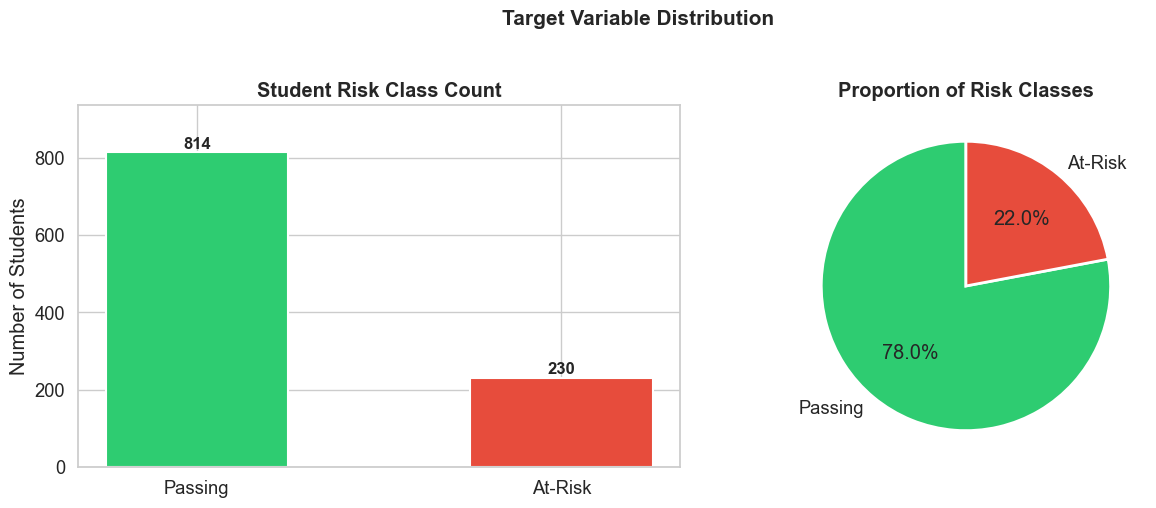

Saved: visuals/01_target_distribution.png


In [41]:
# visualising the class balance — always the first plot in a classification project
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- bar chart ---
counts = df_raw['Risk Status'].value_counts()
# ensuring consistent order: Passing first, At-Risk second
ordered_labels = ['Passing', 'At-Risk']
ordered_counts = [counts['Passing'], counts['At-Risk']]
ordered_colors = [PALETTE['Passing'], PALETTE['At-Risk']]

bars = axes[0].bar(ordered_labels, ordered_counts,
                   color=ordered_colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Student Risk Class Count', fontweight='bold')
axes[0].set_ylabel('Number of Students')
axes[0].set_ylim(0, max(ordered_counts) * 1.15)
for bar, count in zip(bars, ordered_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 str(count), ha='center', fontweight='bold', fontsize=12)

# --- pie chart ---
axes[1].pie(ordered_counts, labels=ordered_labels,
            colors=ordered_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of Risk Classes', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/01_target_distribution.png")

#### Observation: Class Imbalance

My dataset has 67.1% passing students and 32.9% at-risk students. 
This is a **moderately imbalanced** classification problem.

This matters because a naive model that always predicts "passing" 
would achieve 67% accuracy without learning anything useful. 
For this reason I will:

- Use **F1-score, Precision, and Recall** as primary metrics — not accuracy
- Apply **SMOTE** (oversampling) during model training to handle the imbalance
- Pay special attention to **Recall** — I want to minimise missed at-risk students

###  Grade Distribution by Risk

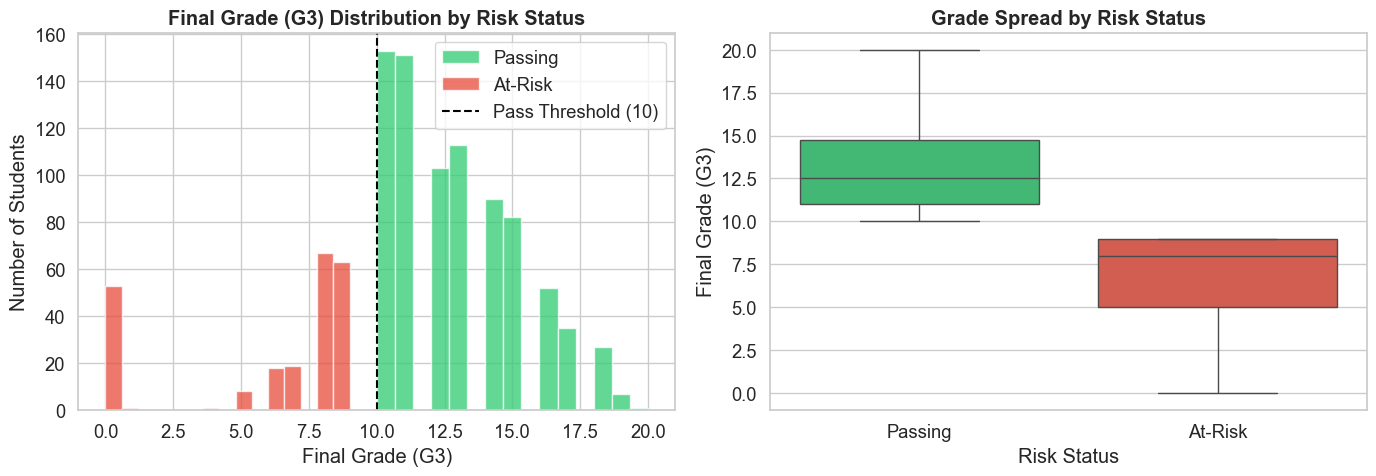

Saved: visuals/02_grade_distribution.png


In [42]:
# comparing final grade distributions between the two groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- histogram ---
for label, color in PALETTE.items():
    risk_val = 0 if label == 'Passing' else 1
    subset = df_raw[df_raw['at_risk'] == risk_val]['G3']
    axes[0].hist(subset, bins=15, alpha=0.75, color=color,
                 label=label, edgecolor='white')

axes[0].axvline(x=10, color='black', linestyle='--',
                linewidth=1.5, label='Pass Threshold (10)')
axes[0].set_title('Final Grade (G3) Distribution by Risk Status', fontweight='bold')
axes[0].set_xlabel('Final Grade (G3)')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# --- box plot ---
# specifying order so Passing is always left (green) and At-Risk right (red)
sns.boxplot(data=df_raw, x='Risk Status', y='G3',
            order=['Passing', 'At-Risk'],
            palette=PALETTE, ax=axes[1])
axes[1].set_title('Grade Spread by Risk Status', fontweight='bold')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.savefig('../visuals/02_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/02_grade_distribution.png")

#### Observation: Grade Distribution

The grade distributions confirm my threshold choice of G3 < 10 is sensible. 
At-risk students are clearly concentrated in the 0–9 range with a notable 
spike at 0 — suggesting a group of students who may have dropped out or 
not sat the exam at all.

Passing students show a roughly normal distribution centred around 12–13.
The box plot confirms minimal overlap between the two groups in terms of 
raw grades, which is expected since G3 directly defines my target variable.

### Absences & Study Time by Risk

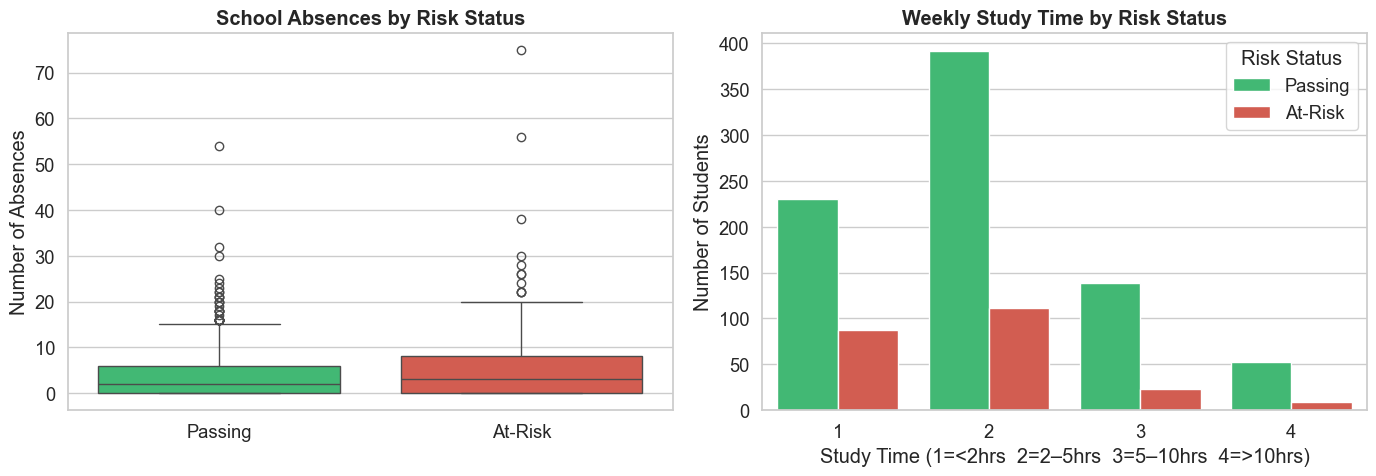

Saved: visuals/03_behavioural_features.png


In [43]:
# studying how absences and study time differ between risk groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- absences box plot ---
sns.boxplot(data=df_raw, x='Risk Status', y='absences',
            order=['Passing', 'At-Risk'],
            palette=PALETTE, ax=axes[0])
axes[0].set_title('School Absences by Risk Status', fontweight='bold')
axes[0].set_ylabel('Number of Absences')
axes[0].set_xlabel('')

# --- study time count plot ---
sns.countplot(data=df_raw, x='studytime', hue='Risk Status',
              hue_order=['Passing', 'At-Risk'],
              palette=PALETTE, ax=axes[1])
axes[1].set_title('Weekly Study Time by Risk Status', fontweight='bold')
axes[1].set_xlabel('Study Time (1=<2hrs  2=2–5hrs  3=5–10hrs  4=>10hrs)')
axes[1].set_ylabel('Number of Students')
axes[1].legend(title='Risk Status')

plt.tight_layout()
plt.savefig('../visuals/03_behavioural_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/03_behavioural_features.png")

#### Observation: Behavioural Features

**Absences:** At-risk students show a wider spread and higher median 
absences compared to passing students. The outliers on the high end 
are almost exclusively at-risk students — consistent with what we'd 
expect in a real school setting.

**Study Time:** Students who study more than 5 hours per week (categories 
3 and 4) are predominantly in the passing group. At-risk students are 
heavily concentrated in the lowest study time category (<2 hours/week).

These two features are likely to be strong predictors in my model.

###  Socioeconomic Features

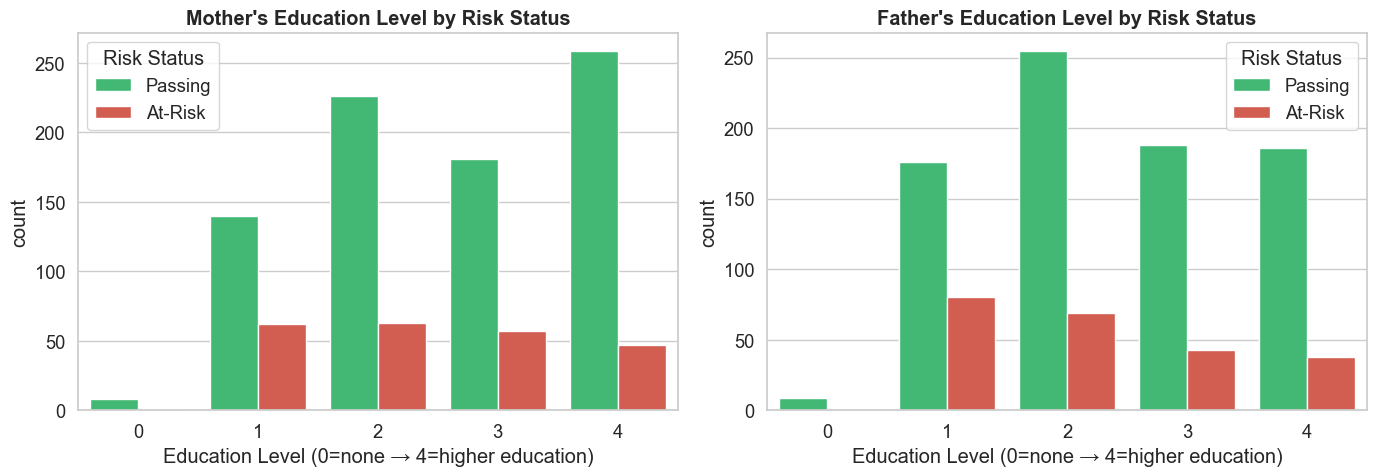

Saved: visuals/04_socioeconomic_features.png


In [44]:
# examining parental education levels across both risk groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_raw, x='Medu', hue='Risk Status',
              hue_order=['Passing', 'At-Risk'],
              palette=PALETTE, ax=axes[0])
axes[0].set_title("Mother's Education Level by Risk Status", fontweight='bold')
axes[0].set_xlabel('Education Level (0=none → 4=higher education)')
axes[0].legend(title='Risk Status')

sns.countplot(data=df_raw, x='Fedu', hue='Risk Status',
              hue_order=['Passing', 'At-Risk'],
              palette=PALETTE, ax=axes[1])
axes[1].set_title("Father's Education Level by Risk Status", fontweight='bold')
axes[1].set_xlabel('Education Level (0=none → 4=higher education)')
axes[1].legend(title='Risk Status')

plt.tight_layout()
plt.savefig('../visuals/04_socioeconomic_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/04_socioeconomic_features.png")

#### Observation: Socioeconomic Features

Students whose parents hold higher education (level 3 or 4) appear 
more frequently in the passing group. Where parental education is 
low (level 0 or 1), the proportion of at-risk students is visibly higher.

This aligns with the academic literature on socioeconomic determinants 
of student performance. I will create a combined parental education 
feature during feature engineering to capture this signal more efficiently 
as a single variable.

### Past Failures & Alcohol

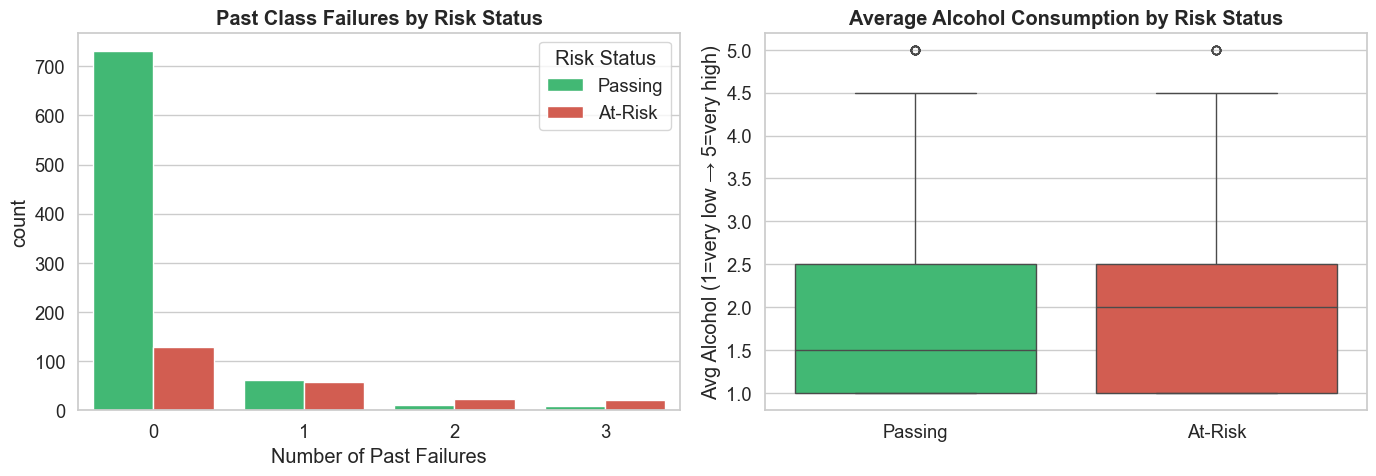

Saved: visuals/05_failures_alcohol.png


In [45]:
# past failures and alcohol consumption — two features expected to be strong predictors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_raw, x='failures', hue='Risk Status',
              hue_order=['Passing', 'At-Risk'],
              palette=PALETTE, ax=axes[0])
axes[0].set_title('Past Class Failures by Risk Status', fontweight='bold')
axes[0].set_xlabel('Number of Past Failures')
axes[0].legend(title='Risk Status')

# combining weekday and weekend alcohol into average consumption
df_raw['avg_alcohol'] = (df_raw['Dalc'] + df_raw['Walc']) / 2
sns.boxplot(data=df_raw, x='Risk Status', y='avg_alcohol',
            order=['Passing', 'At-Risk'],
            palette=PALETTE, ax=axes[1])
axes[1].set_title('Average Alcohol Consumption by Risk Status', fontweight='bold')
axes[1].set_ylabel('Avg Alcohol (1=very low → 5=very high)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../visuals/05_failures_alcohol.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/05_failures_alcohol.png")

#### Observation: Past Failures and Alcohol Consumption

**Past Failures:** This is the most visually striking feature so far. 
Students with 1 or more past failures are disproportionately in the 
at-risk group. Students with 0 failures are overwhelmingly passing. 
This will almost certainly be the strongest single predictor in my model.

**Alcohol Consumption:** At-risk students show a slightly higher median 
alcohol consumption. The effect is present but less dramatic than failures 
or absences. I previewed this feature here — I will formally engineer 
an average alcohol score in the next notebook.

### Correlation Heatmap

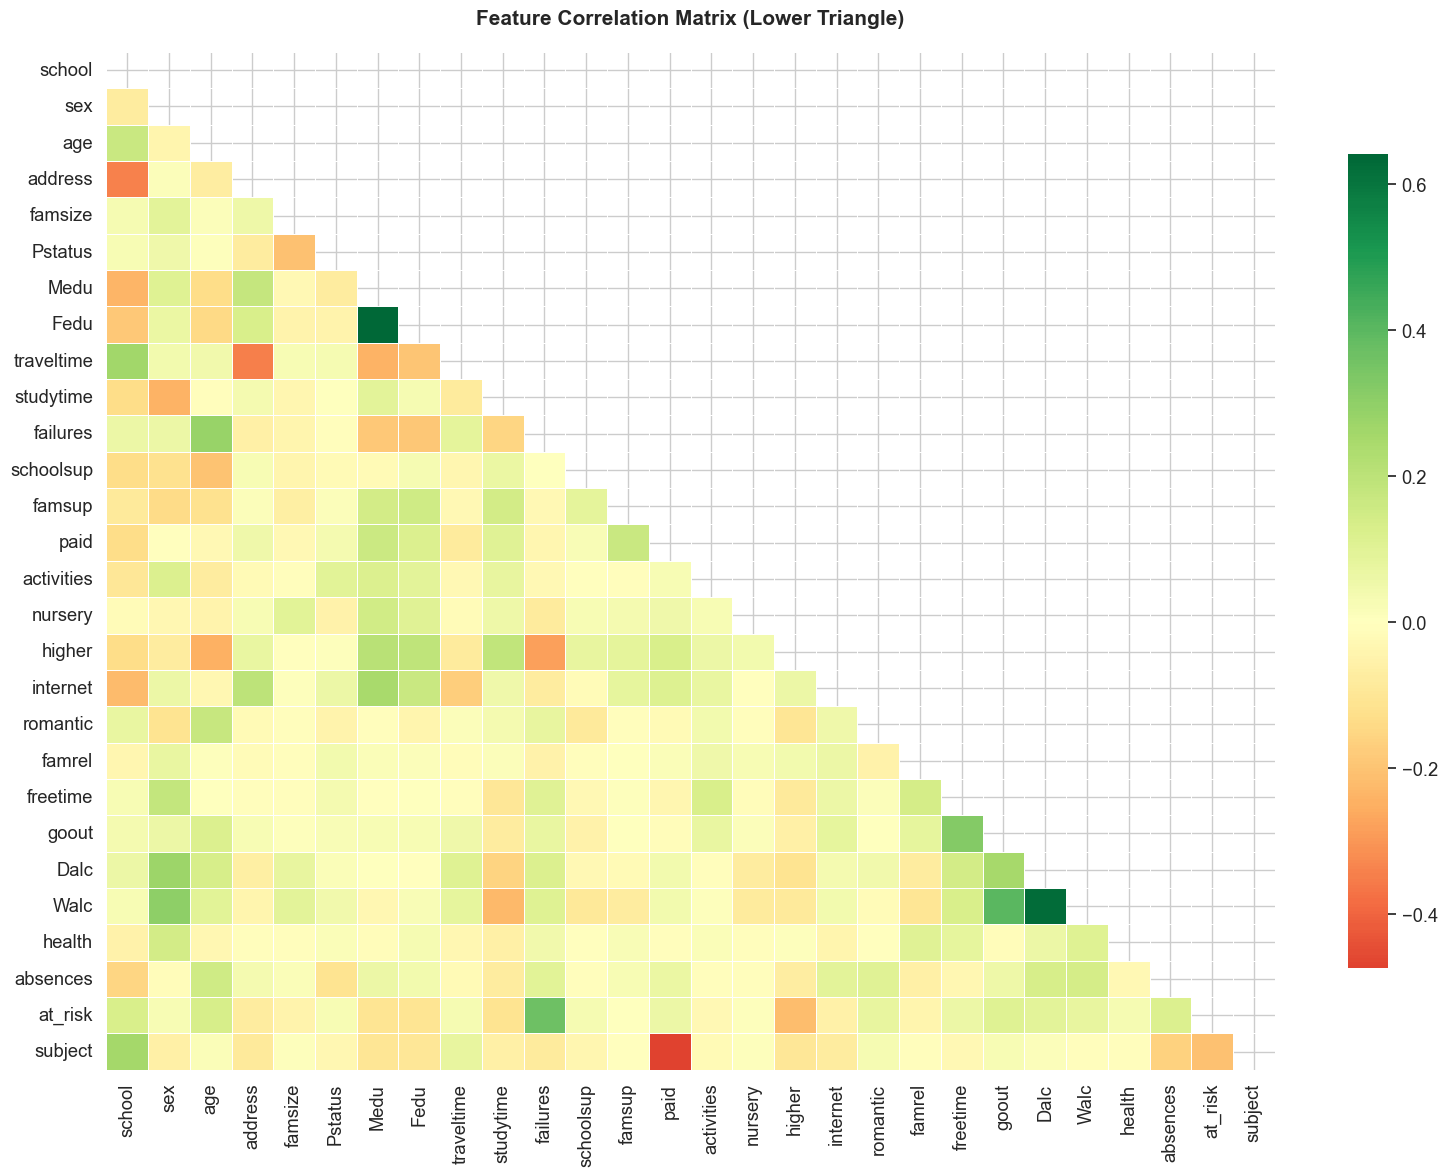

Saved: visuals/06_correlation_heatmap.png


In [46]:
# computing pairwise correlations across all numerical features
numerical_features = df_clean.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_features.corr()

# plotting lower triangle only to avoid redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, annot=False,
            cmap='RdYlGn', center=0,
            linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Lower Triangle)',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../visuals/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/06_correlation_heatmap.png")

#### Top Correlations with Target

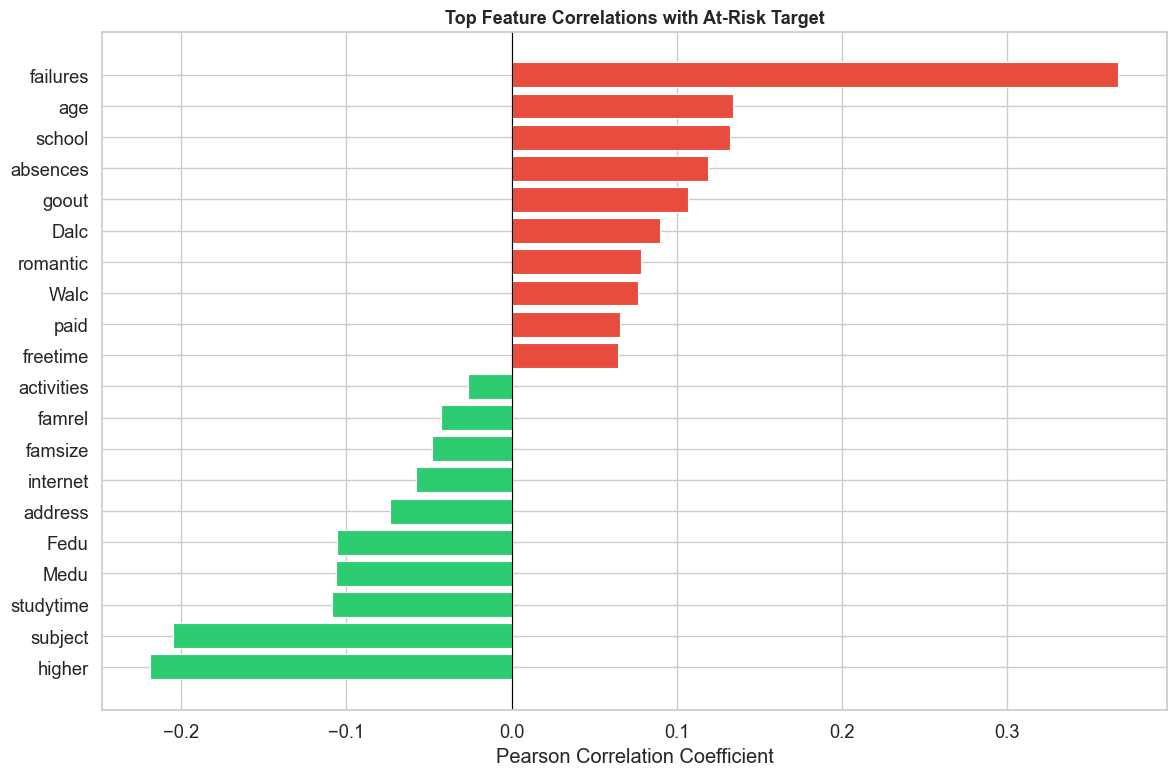

Risk-increasing features (positive correlation):
goout       0.107
absences    0.119
school      0.132
age         0.134
failures    0.367
Name: at_risk, dtype: float64

Protective features (negative correlation):
higher      -0.218
subject     -0.205
studytime   -0.109
Medu        -0.106
Fedu        -0.106
Name: at_risk, dtype: float64


In [47]:
# isolating which features have the strongest linear relationship with at_risk
target_corr = (corr_matrix['at_risk']
               .drop('at_risk')
               .sort_values())

top_corr = pd.concat([target_corr.head(10), target_corr.tail(10)])

# coloring bars: positive correlation = red (risk-increasing),
#                negative correlation = green (protective)
bar_colors = [PALETTE['At-Risk'] if v > 0 else PALETTE['Passing']
              for v in top_corr.values]

plt.figure(figsize=(12, 8))
plt.barh(top_corr.index, top_corr.values,
         color=bar_colors, edgecolor='white', linewidth=0.8)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top Feature Correlations with At-Risk Target',
          fontweight='bold', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../visuals/07_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Risk-increasing features (positive correlation):")
print(target_corr.tail(5).round(3))
print("\nProtective features (negative correlation):")
print(target_corr.head(5).round(3))

#### Observation: Feature Correlations with At-Risk Target

The correlation bar chart uses the same colour convention as every 
other chart — red bars indicate features that increase risk (positive 
correlation with at_risk) and green bars indicate protective features 
(negative correlation).

**Risk-increasing:** Past failures and high alcohol consumption show 
the strongest positive correlations with at_risk.

**Protective:** Study time, parental education, and aspiration for 
higher education show the strongest negative correlations.

**Important caveat:** These are linear correlations only. Tree-based 
models like XGBoost can capture non-linear relationships that this 
matrix does not show. SHAP values after modelling will give a more 
complete picture of true feature importance.

###  Interactive Plotly Chart

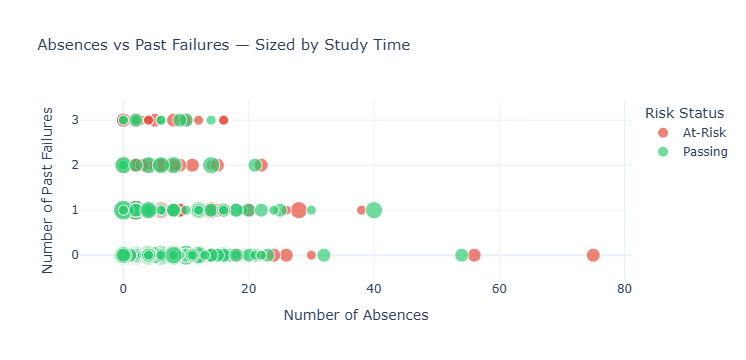

Saved: visuals/08_interactive_scatter.html


In [48]:
# interactive scatter to explore individual student profiles
fig = px.scatter(
    df_raw,
    x='absences',
    y='failures',
    color='Risk Status',
    color_discrete_map=PALETTE,
    size='studytime',
    hover_data=['age', 'G3', 'studytime', 'subject'],
    title='Absences vs Past Failures — Sized by Study Time',
    labels={
        'absences': 'Number of Absences',
        'failures': 'Number of Past Failures'
    },
    template='plotly_white'
)
fig.update_layout(title_font_size=15)
fig.write_html('../visuals/08_interactive_scatter.html')
fig.show()
print("Saved: visuals/08_interactive_scatter.html")

## EDA Summary — Key Takeaways

After completing the exploratory analysis, here are the patterns 
I will carry forward into feature engineering:

| Feature | Finding |
|---|---|
| Past Failures | Strongest single separator between groups |
| Absences | Higher median and spread in at-risk group |
| Study Time | Low study time strongly associated with risk |
| Parental Education | Higher education = lower risk for both parents |
| Alcohol Consumption | Elevated in at-risk group — will engineer avg score |

**Design decisions confirmed by EDA:**
- Threshold of G3 < 10 is appropriate and produces clean separation
- Class imbalance (67/33) is moderate — SMOTE will be applied
- No single feature perfectly separates classes — an ensemble model is appropriate
- Correlation analysis is linear only — SHAP will reveal the full picture post-modelling